# Test Layer1 (2020 RF + Road Class)

This notebook reproduces a simple 2020 Layer-1 RandomForest baseline and **adds `fclass`** as a feature.
It is designed for direct comparison against your original 2020 RF results.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid')

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'

PARQ_DIR = DATA_DIR / 'ghana_parquet'
PBF_PATH = DATA_DIR / 'ghana-260415.osm.pbf'

if not PARQ_DIR.exists():
    raise FileNotFoundError(f'Missing parquet dir: {PARQ_DIR}')
if not PBF_PATH.exists():
    raise FileNotFoundError(f'Missing PBF file: {PBF_PATH}')

print('DATA_DIR:', DATA_DIR)


DATA_DIR: /Users/miranda/Documents/GitHub/Sentinel-FYP/data


In [2]:
# Load 2020 parquet rows
p2020 = PARQ_DIR / 'year=2020'
if not p2020.exists():
    raise FileNotFoundError(f'Missing partition: {p2020}')

files = sorted(p2020.glob('*.parquet'))
if not files:
    raise FileNotFoundError(f'No parquet files in {p2020}')

parts = [pd.read_parquet(f) for f in files]
df = pd.concat(parts, ignore_index=True)
df['year'] = 2020

# Keep core columns
keep = ['osm_id','fclass','year','quarter','NDVI','NDMI','NDBI','NDWI','BSI']
missing = [c for c in keep if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns in 2020 parquet: {missing}')

df = df[keep].copy()
df['osm_id'] = df['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
df['fclass'] = df['fclass'].astype(str).str.strip().str.lower()
for c in ['NDVI','NDMI','NDBI','NDWI','BSI']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.drop_duplicates(subset=['osm_id','quarter'], keep='last')
print('2020 rows:', len(df))
print('2020 unique roads:', df['osm_id'].nunique())


2020 rows: 1316416
2020 unique roads: 329104


In [3]:
# Build Layer-1 labels (paved/unpaved) from OSM surface in PBF
import pyrosm

osm = pyrosm.OSM(str(PBF_PATH))
roads = osm.get_network(network_type='driving', extra_attributes=['surface'])
if roads is None or roads.empty:
    raise RuntimeError('Could not extract roads from PBF')

roads = roads[['id','surface']].copy().rename(columns={'id':'osm_id'})
roads['osm_id'] = roads['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
roads['surface'] = roads['surface'].astype(str).str.strip().str.lower()

paved_vals = {
    'asphalt', 'concrete', 'paved', 'paving_stones', 'sett',
    'concrete:lanes', 'concrete:plates', 'metal', 'wood'
}
unpaved_vals = {
    'unpaved', 'gravel', 'dirt', 'ground', 'earth', 'sand',
    'mud', 'grass', 'compacted', 'fine_gravel', 'pebblestone', 'clay'
}

def map_layer1(surface):
    if pd.isna(surface):
        return np.nan
    s = str(surface).strip().lower()
    if s in paved_vals:
        return 'paved'
    if s in unpaved_vals:
        return 'unpaved'
    if any(k in s for k in ['asphalt','concrete','paved']):
        return 'paved'
    if any(k in s for k in ['gravel','dirt','earth','ground','sand','mud','unpaved']):
        return 'unpaved'
    return np.nan

label_df = roads[['osm_id','surface']].drop_duplicates('osm_id').copy()
label_df['layer1_label_large'] = label_df['surface'].map(map_layer1)
label_df = label_df.dropna(subset=['layer1_label_large'])[['osm_id','layer1_label_large']]

print('Label rows:', len(label_df))
print(label_df['layer1_label_large'].value_counts())


/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


Label rows: 30467
layer1_label_large
unpaved    17131
paved      13336
Name: count, dtype: int64


In [4]:
# Merge labels + aggregate to road-level features (2020 only)
m = df.merge(label_df, on='osm_id', how='inner')

print('Merged quarterly rows:', len(m))
print('Merged unique roads:', m['osm_id'].nunique())
print('Class balance (%):')
print(m['layer1_label_large'].value_counts(normalize=True).mul(100).round(2))

# Aggregate numeric indices over quarters per road
idx_cols = ['NDVI','NDMI','NDBI','NDWI','BSI']
agg = m.groupby(['osm_id','layer1_label_large'], as_index=False).agg(
    NDVI_mean=('NDVI','mean'), NDVI_std=('NDVI','std'),
    NDMI_mean=('NDMI','mean'), NDMI_std=('NDMI','std'),
    NDBI_mean=('NDBI','mean'), NDBI_std=('NDBI','std'),
    NDWI_mean=('NDWI','mean'), NDWI_std=('NDWI','std'),
    BSI_mean=('BSI','mean'), BSI_std=('BSI','std'),
)

# Add road class as feature (one-hot from most frequent class per road)
fclass_mode = (
    m[['osm_id','fclass']]
    .dropna()
    .groupby('osm_id')['fclass']
    .agg(lambda s: s.value_counts().index[0])
    .reset_index()
)

agg = agg.merge(fclass_mode, on='osm_id', how='left')
agg['fclass'] = agg['fclass'].fillna('unknown')

fclass_ohe = pd.get_dummies(agg['fclass'], prefix='fclass', dtype=int)
agg = pd.concat([agg.drop(columns=['fclass']), fclass_ohe], axis=1)

feature_cols = [c for c in agg.columns if c not in ['osm_id','layer1_label_large']]
agg[feature_cols] = agg[feature_cols].apply(pd.to_numeric, errors='coerce')

# missingness flags + median fill
na_cols = [c for c in feature_cols if agg[c].isna().any()]
if na_cols:
    na_flags = agg[na_cols].isna().astype(int)
    na_flags.columns = [f'{c}_isna' for c in na_cols]
    agg = pd.concat([agg, na_flags], axis=1)

feature_cols = [c for c in agg.columns if c not in ['osm_id','layer1_label_large']]
med = agg[feature_cols].median(numeric_only=True)
agg[feature_cols] = agg[feature_cols].fillna(med).fillna(0)

print('Road-level rows:', len(agg))
print('Feature count:', len(feature_cols))


Merged quarterly rows: 118580
Merged unique roads: 29645
Class balance (%):
layer1_label_large
unpaved    57.05
paved      42.95
Name: proportion, dtype: float64
Road-level rows: 29645
Feature count: 27


2020 RF + fclass report:
              precision    recall  f1-score   support

       paved      0.817     0.781     0.798      2547
     unpaved      0.840     0.868     0.854      3382

    accuracy                          0.831      5929
   macro avg      0.829     0.825     0.826      5929
weighted avg      0.830     0.831     0.830      5929



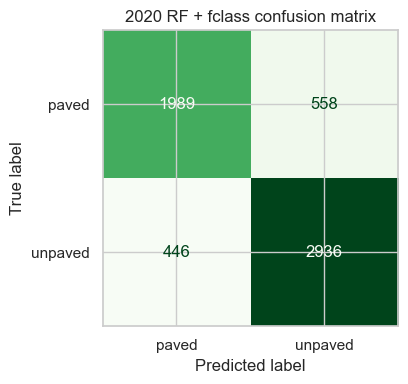

,importance
NDWI_mean,0.174418
NDVI_mean,0.122547
NDVI_std,0.082828
fclass_residential,0.078218
BSI_mean,0.067447
NDBI_std,0.064475
NDMI_std,0.064307
BSI_std,0.061528
NDBI_mean,0.059396
NDMI_mean,0.058853


In [5]:
# Train/test RF (same simple style baseline as original 2020 run)
X = agg[feature_cols].copy()
y = agg['layer1_label_large'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_2020_fclass = RandomForestClassifier(
    n_estimators=900,
    random_state=42,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf_2020_fclass.fit(X_train, y_train)
pred = rf_2020_fclass.predict(X_test)

print('2020 RF + fclass report:')
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=['paved','unpaved'])
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=['paved','unpaved']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('2020 RF + fclass confusion matrix')
plt.tight_layout()
plt.show()

imp = pd.Series(rf_2020_fclass.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(imp.head(25).to_frame('importance'))


## Comparison Note
Compare this notebook's metrics against your original 2020 RF notebook run.
If needed, we can add a side-by-side table in this notebook once you paste the baseline metrics.
